# Assignment 12: Predicting Hotel Booking Cancellations  
## Models: Naïve Bayes, Support Vector Machine (SVM), and Neural Network

**Objectives:**
- Understand how to use classification models (Naïve Bayes, SVM, Neural Networks) to predict hotel cancellations.
- Compare models in terms of accuracy, complexity, and business relevance.
- Interpret and communicate model results from a business perspective.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Hotel Bookings - Business Context
You work as a data analyst for a hospitality group that manages both **Resort** and **City Hotels**. One major challenge in operations is the unpredictability of **booking cancellations**, which affects staffing, inventory, and revenue planning.

You’ve been asked to use historical booking data to predict whether a future booking will be canceled. Your insights will help management plan more effectively.

Your tasks are to:
1. Build and evaluate three models: Naïve Bayes, SVM, and Neural Network.
2. Compare performance.
3. Recommend which model is best suited for the business needs.

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance




## Data Dictionary

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Load and Prepare the Hotel Booking Dataset

**Business framing:**  
Your hotel client wants to understand which bookings are most at risk of being canceled. But before modeling, your job is to prepare the data to ensure clean and reliable input.

### Do the following:
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Remove or impute missing values
- Encode categorical variables
- Create your `X` (features) and `y` (target = `is_canceled`)
- Split the data into training and test sets (70/30)

**Important:** Perform this split **before** any preprocessing or feature transformations.

### In Your Response:
1. How many total rows and columns are in the dataset?
2. What types of features (categorical, numerical) are included?
3. What steps did you take to clean or prepare the data?


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the dataset
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv"
df = pd.read_csv(url)

print(f"Initial dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

df = df.drop(columns=['reservation_status', 'reservation_status_date', 'company', 'agent', 'country'])

# Identify target variable
y = df['is_canceled']
X = df.drop('is_canceled', axis=1)

# Split data into training and test sets (70/30) BEFORE preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


# Impute missing values for numerical features with the median of the training set
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True) # Use median from train set for test set

# Impute missing values for categorical features with the mode of the training set
categorical_cols = X_train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True) # Use mode from train set for test set

# Encode categorical variables using one-hot encoding
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

aligned_cols = list(X_train.columns)
X_test = X_test.reindex(columns=aligned_cols, fill_value=0)

print(f"\nShape of X_train after preprocessing: {X_train.shape}")
print(f"Shape of X_test after preprocessing: {X_test.shape}")

# Display first few rows of preprocessed data
print("\nX_train head after preprocessing:")
display(X_train.head())


Initial dataset shape: 9404 rows, 32 columns

Shape of X_train: (6582, 26)
Shape of X_test: (2822, 26)
Shape of y_train: (6582,)
Shape of y_test: (2822,)

Shape of X_train after preprocessing: (6582, 60)
Shape of X_test after preprocessing: (2822, 60)

X_train head after preprocessing:


/tmp/ipykernel_7231/3431752408.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(median_val, inplace=True)
/tmp/ipykernel_7231/3431752408.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
8212,4,2017,31,1,0,1,1,0,0,1,...,False,False,False,False,False,False,False,False,True,False
1469,26,2015,36,31,1,2,2,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1710,140,2015,37,10,2,5,2,1,0,0,...,False,False,False,False,False,False,False,False,True,False
8507,0,2015,49,30,1,3,1,0,0,0,...,False,False,False,False,False,False,False,False,False,True
9127,0,2015,52,26,0,1,2,0,1,0,...,False,False,False,False,False,False,False,False,True,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal                            94

1. The data set has 9404 rows between 32 coloumns.
2. There are 9 categorical columns and the remnaing are numerical data values
3. For data cleaning I filled missing numerical values with the median and non-numerical values with the mode, I then one hot encoded the data as well.

## 2. Build a Naïve Bayes Model

**Business framing:**  
Naïve Bayes is a quick, baseline model often used for early testing or simple classification problems.

### Do the following:
- Make sure to split your data first (see the previous step), then fit any text/vector preprocessing on training data only.
- Train a Naïve Bayes classifier on your training data
- Use it to predict on your test data
- Print a classification report and confusion matrix

**Note:** If you use a vectorizer (e.g., `CountVectorizer`), fit it on the training data only, then transform both training and test data.

### In Your Response:
1. How well does the model perform?  And what metric is best used to judge the performance?
2. Where might this model be useful for the hotel (e.g. real-time alerts, operational decisions)?


Naïve Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.43      0.59      2111
           1       0.36      0.93      0.51       711

    accuracy                           0.56      2822
   macro avg       0.65      0.68      0.55      2822
weighted avg       0.80      0.56      0.57      2822



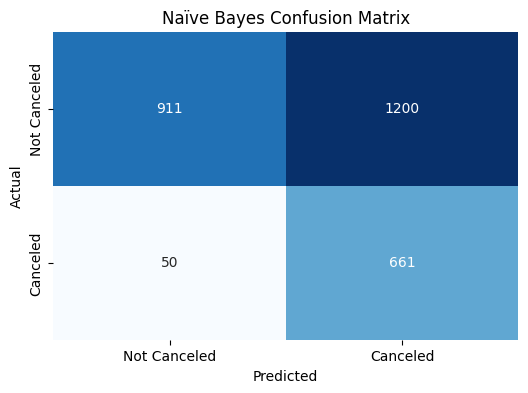

In [5]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Naïve Bayes Classifier
nb_model = GaussianNB()

# Train the model on the training data
nb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_nb = nb_model.predict(X_test)

# Print classification report
print("Naïve Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

# Plot confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title('Naïve Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### ✍️ Your Response: 🔧
1. The accuracy was a modest 0.56 which not considered super reliable but its not a poor accuracy either. The model did great at prediciting "canceled" at  
.91

2. Within a hotel business context this model does well at predicting/explaining canceled but is not good overall at explaining other business variables that might need to be explained, for that reason the model would generally have poor to modest reliablity overall when making multi variable business decisons or business analysis.

## 3. Build a Support Vector Machine (SVM) Model

**Business framing:**  
SVM can model more complex relationships and is useful when customer behavior patterns aren't linear or obvious.

### Do the following:
- Scale the data using `StandardScaler` to bring large numbers into a smaller range (Note: use a scaled training set, but fit the scaler only on X_train).
- Train an SVM classifier (use `linear` kernel)
- Make predictions and evaluate with classification metrics

**NOTE:** With about 10K rows, this model may run very **slow**.  Be prepared to wait up to 10 minutes.   

### In Your Response:
1. How well does the model perform?  And what metric is best used to judge the performance?
2. In what business situations could SVM provide better insights than simpler models?


Training SVM model... This might take a while.
SVM model training complete.

Support Vector Machine (SVM) Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      2111
           1       0.95      0.44      0.61       711

    accuracy                           0.85      2822
   macro avg       0.90      0.72      0.76      2822
weighted avg       0.87      0.85      0.83      2822



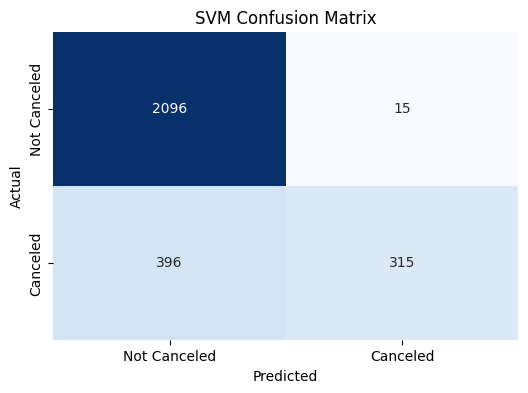

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVM Classifier with a linear kernel
svm_model = SVC(kernel='linear', random_state=42)

# Train the model on the scaled training data
print("Training SVM model... This might take a while.")
svm_model.fit(X_train_scaled, y_train)
print("SVM model training complete.")

# Make predictions on the scaled test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Print classification report
print("\nSupport Vector Machine (SVM) Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Plot confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### ✍️ Your Response: 🔧
1. This model seemed to be a significant improvement over the first one and overall performed quite well. The precision score for 0 and 1 were 0.84 and 0.95 respectively, and the overall f-1 score was 0.85 out of 1, which gives the model quite high accuracy.

2. This model had not only much better prescion for both 0 and 1 and better accuracy, so making generalized business decisions could be done much more reliabily with this model over the first one.

## 4. Build a Neural Network Model

**Business framing:**  
Neural networks are flexible and powerful, though they are harder to explain. They may work well when subtle patterns exist in the data.

### Do the following:
- Build a MLPClassifier model using the neural_network package from sklearn
- Choose a simple architecture (e.g., 2 hidden layers)
- Use a true validation split from the training data, not the test set, for validation_data
- Evaluate accuracy and performance

**NOTE:** With about 10K rows, this model may run very **slow**.  Be prepared to wait up to 10 minutes.  

### In Your Response:
1. How does this model compare to the others?
2. Would the business be comfortable using a “black box” model like this? Why or why not?


Training Neural Network model... This might take a while.
Neural Network model training complete.

Neural Network (MLPClassifier) Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      2111
           1       0.81      0.65      0.72       711

    accuracy                           0.87      2822
   macro avg       0.85      0.80      0.82      2822
weighted avg       0.87      0.87      0.87      2822



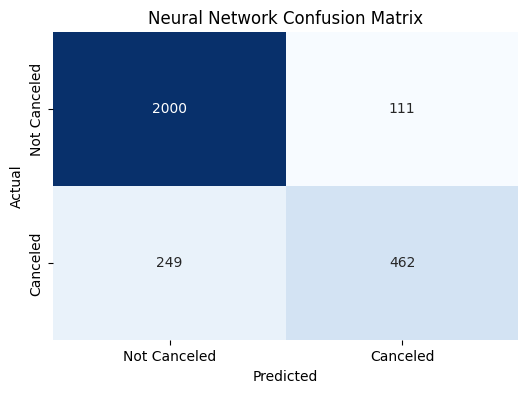

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, activation='relu', solver='adam', random_state=42, early_stopping=True, validation_fraction=0.1)

# Train the model on the scaled training data
print("Training Neural Network model... This might take a while.")
mlp_model.fit(X_train_scaled, y_train)
print("Neural Network model training complete.")

# Make predictions on the scaled test data
y_pred_mlp = mlp_model.predict(X_test_scaled)

# Print classification report
print("\nNeural Network (MLPClassifier) Classification Report:")
print(classification_report(y_test, y_pred_mlp))

# Plot confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### ✍️ Your Response: 🔧
1. This model in terms of the precision metrics, accuracy and confusion matrix seems to be very similar to the second model and better suited for business analytics compared to the first. The differences are very negligible between this model and the second, in terms of accuracy metrics and results.

2. That depends on if they are looking for a why answer, or simply looking for models to analyze so they can make thier own inferences. If a business is looking for a "why" inference in their model a black box model would not be preferable. If a business wanted to curate thier own inference a black box model woudl be sufficient.

## 5. Compare All Three Models

### Do the following:
- Print and compare the accuracy of Naïve Bayes, SVM, and Neural Network models
- Summarize which model performed best

### In Your Response:
1. Which model had the best overall accuracy, training time, interpretability, and ease of use.
2. Would you recommend this model for deployment, and why?



Neural Network (MLPClassifier) Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      2111
           1       0.81      0.65      0.72       711

    accuracy                           0.87      2822
   macro avg       0.85      0.80      0.82      2822
weighted avg       0.87      0.87      0.87      2822



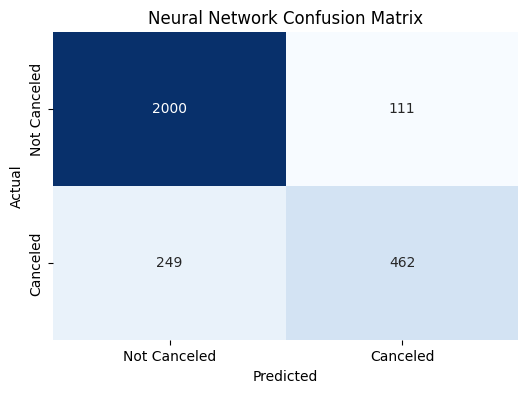


Support Vector Machine (SVM) Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      2111
           1       0.95      0.44      0.61       711

    accuracy                           0.85      2822
   macro avg       0.90      0.72      0.76      2822
weighted avg       0.87      0.85      0.83      2822



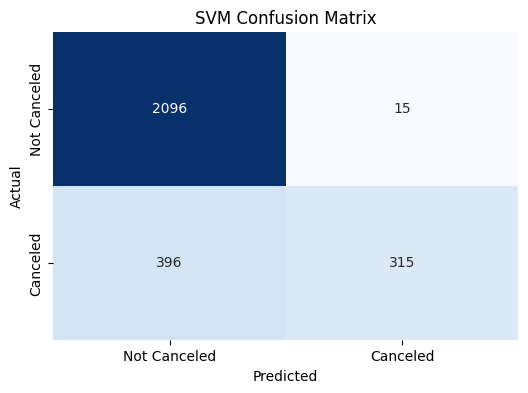

Naïve Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.43      0.59      2111
           1       0.36      0.93      0.51       711

    accuracy                           0.56      2822
   macro avg       0.65      0.68      0.55      2822
weighted avg       0.80      0.56      0.57      2822



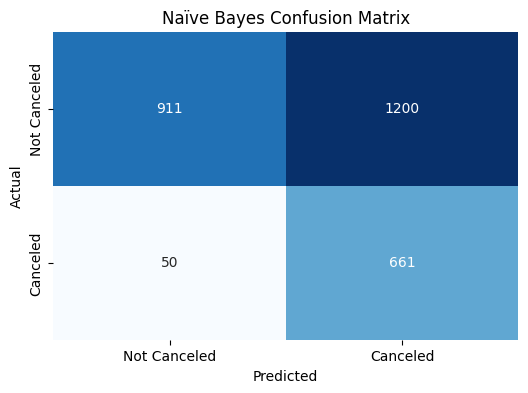

In [9]:
# Add code here 🔧
print("\nNeural Network (MLPClassifier) Classification Report:")
print(classification_report(y_test, y_pred_mlp))

# Plot confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nSupport Vector Machine (SVM) Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Plot confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Naïve Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

# Plot confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title('Naïve Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### ✍️ Your Response: 🔧
1. The second and third model had very simialr performance, I would give a slight edge to the second model as the 0 and 1 precision were consistently higher.

2. Based on the results I would be comfortable using either the second or third model, the Naive Bayes one being the only one I would not consider reliable for bsuiness applications.

## 6. Final Business Recommendation

### In Your Response:
1. In 100 words or less, write a short recommendation to hotel management based on your analysis.

Possible info to include:
- Which model do you recommend implementing?
- What business problem does it help solve?
- Are there any risks or limitations?
- What additional data might improve the results in the future?
2. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. I would feel most confident in model 2 due to the accuracy and precision results comapred to the first and third, although the third model was very closely behhind.

2. These models do a good job at provding prescriptive and predictive data with high amounts of noise and high volume of data due to the accuracy and precision outputs. Gving business easy interpretibility and decision making ability with large volume data

3. The models inherintely carry error risk which is why the accuracy coefficient has to be weighed carefully when using models for business decisions

4. Further cleaning such as the removing of extreme outliers or create classes that weigh different classes proportionally may help improve accuracy if models are resulting in low accuracy results

5. This assignment really focused more on interpretation than code skills so for me this applies to my complex analysis learning outcome.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_12_bayes_svm_neural.ipynb"